In [1]:
import snappy
import numpy as np
import matplotlib.pyplot as plt
from sympy.solvers import solve_linear
from sympy.plotting.plot_implicit import plot_implicit
from sympy import Symbol, Abs, symbols

# Plot Knot Geography $T(p,q)$
Gordon-Litherland signature bound:
$$
W_\sigma = \left\{
2b \ge \left| e - 2\sigma(K) \right|
\right\}
$$

In [53]:
def plot_sig_bound(K, erange=(-20,20), brange=(0,20)):
    sigma = K.signature()
    e_symb, b_symb = symbols('e b')

    int_points = [(e,b) 
                  for e in range(erange[0], erange[1]+1) 
                  for b in range(brange[0], brange[1]+1)]

    realizable_points = [(e,b) for e,b in int_points if 2*b >= abs(e - 2 * sigma)]
    realizable_e = [e for e,_ in realizable_points]
    realizable_b = [b for _,b in realizable_points]

    fig, ax = plt.subplots()
    ax.scatter(realizable_e, realizable_b, s=2, c='red')

    sympy_plot = plot_implicit(2*b_symb - Abs(e_symb - 2 * sigma) >= 0,
                               x_var=(e_symb, erange[0], erange[1]), y_var=(b_symb, brange[0], brange[1]),
                               xlabel="$e$", ylabel="$b_1$", line_color="gray", #show=False,
                               fig=fig, ax=ax)

    #fig = sympy_plot._backend._plotgrid_fig
    #ax = sympy_plot._backend._plotgrid_ax

    #fig.canvas.draw()
    return sympy_plot

### TODO - plot integer points
### TODO - fix axis label position

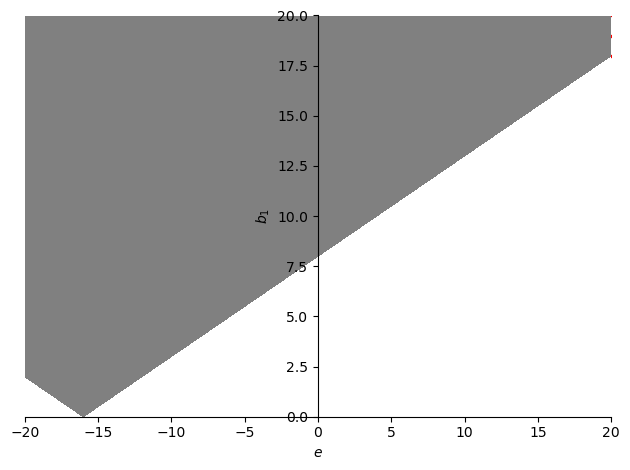

In [54]:
T45 = snappy.Link('T(4,5)')
p = plot_sig_bound(T45)